In [1]:
import numpy as np

In [2]:
# 1. Ridge==>reduce the effect of some features/parameters;L2 reqularization 
# 2. Lasso==>Automatic feature selection by making some parematers 0: L1 regularization
# 3. Elastic ==> Lasso and Ridge 

In [3]:
x= np.linspace(-10,10,8)

In [4]:
y= 5+4*x-3*x**2+np.random.random(8)*100

In [5]:
x

array([-10.        ,  -7.14285714,  -4.28571429,  -1.42857143,
         1.42857143,   4.28571429,   7.14285714,  10.        ])

In [6]:
y

array([-296.15358551, -100.78827064,  -64.99884807,   60.57825481,
         50.1418954 ,  -31.05273528,  -48.82380757, -225.21894427])

In [7]:
from matplotlib import pyplot as plt

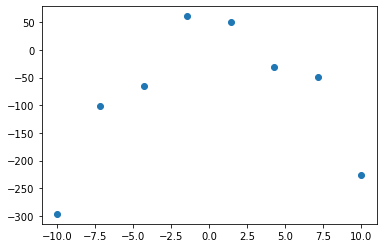

In [8]:
plt.scatter(x,y)

In [14]:
X=x.reshape(-1,1)
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

In [27]:
def compute_poly_model_train_test_values(X,y,degree=2,test_size=0.25):
    poly_transformer=PolynomialFeatures(degree=degree)
#     print(X[:4])
    X=poly_transformer.fit_transform(X)
#     print(X[:4])
    X_train,X_test,y_train,y_test=train_test_split(X,y,
                                                   test_size=test_size,
                                                   
                                               random_state=90,
#                                                    shuffle=False
                                                  )
    model =LinearRegression()
    model.fit(X_train,y_train)
    y_pred_train=model.predict(X_train)
    rmse_train=mean_squared_error(y_train,y_pred_train)**0.5
    r2_train=model.score(X_train,y_train)
    
    y_pred_test=model.predict(X_test)
    rmse_test=mean_squared_error(y_test,y_pred_test)**0.5
    r2_test=model.score(X_test,y_test)
    return {
            "testing accuracy":r2_test,
            "training accuracy":r2_train,
            "rmse_test":rmse_test,
            "rmse_train":rmse_train,
            "intercept":model.intercept_,
            "coeff":model.coef_,
            "model":model,
            "X":X
           }

In [28]:
def compute_and_visualize(X,y,degree=2,test_size=0.25):
    result =compute_poly_model_train_test_values(X,y,degree=2,test_size=0.25)
    y_pred_quad=result["model"].predict(result["X"])
    del result["X"]
    print(result)
    plt.scatter(x,y)
    plt.plot(x,y_pred_quad,"r")
    

{'testing accuracy': -1.687367039759406, 'training accuracy': 0.97006463505103, 'rmse_test': 42.593167845186684, 'rmse_train': 23.106442201627527, 'intercept': 36.99759898607607, 'coeff': array([ 0.        ,  3.48780616, -3.02591426]), 'model': LinearRegression()}


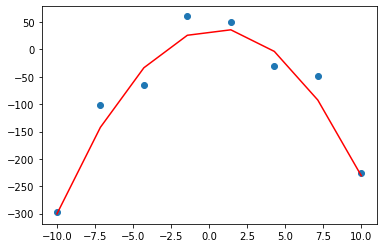

In [29]:
compute_and_visualize(X,y,degree=8,test_size=0.1)

{'testing accuracy': -1.687367039759406, 'training accuracy': 0.97006463505103, 'rmse_test': 42.593167845186684, 'rmse_train': 23.106442201627527, 'intercept': 36.99759898607607, 'coeff': array([ 0.        ,  3.48780616, -3.02591426]), 'model': LinearRegression()}


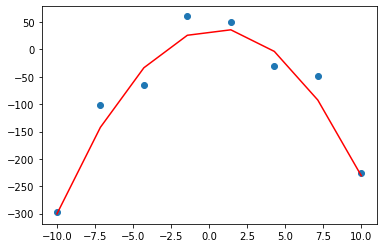

In [30]:
compute_and_visualize(X,y,degree=8,test_size=0.1)

In [45]:
from sklearn.linear_model import Ridge,Lasso, ElasticNet

In [42]:
def compute_poly_model_ridge_train_test_values(X,y,degree=2,test_size=0.25):
    poly_transformer=PolynomialFeatures(degree=degree)
#     print(X[:4])
    X=poly_transformer.fit_transform(X)
#     print(X[:4])
    X_train,X_test,y_train,y_test=train_test_split(X,y,
                                                   test_size=test_size,
                                                   
                                               random_state=41,
#                                                    shuffle=False
                                                  )
    model =Lasso(10)
    model.fit(X_train,y_train)
    y_pred_train=model.predict(X_train)
    rmse_train=mean_squared_error(y_train,y_pred_train)**0.5
    r2_train=model.score(X_train,y_train)
    
    y_pred_test=model.predict(X_test)
    rmse_test=mean_squared_error(y_test,y_pred_test)**0.5
    r2_test=model.score(X_test,y_test)
    return {
            "testing accuracy":r2_test,
            "training accuracy":r2_train,
            "rmse_test":rmse_test,
            "rmse_train":rmse_train,
            "intercept":model.intercept_,
            "coeff":model.coef_,
            "model":model,
            "X":X
           }

In [43]:
def compute_and_visualize_ridge(X,y,degree=2,test_size=0.25):
    result =compute_poly_model_ridge_train_test_values(X,y,degree=2,test_size=0.25)
    y_pred_quad=result["model"].predict(result["X"])
    del result["X"]
    print(result)
    plt.scatter(x,y)
    plt.plot(x,y_pred_quad,"r")

{'testing accuracy': -16.15251675766922, 'training accuracy': 0.967532135905564, 'rmse_test': 36.79997840997315, 'rmse_train': 23.679203200045688, 'intercept': 49.555363614051146, 'coeff': array([ 0.        ,  3.07255482, -3.06672997]), 'model': Lasso(alpha=10)}


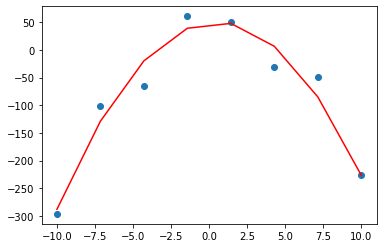

In [44]:
compute_and_visualize_ridge(X,y,degree=8,test_size=0.1)

In [ ]:
ridge_model.fit()